Задани для практических занятий к самостоятельной работы к главе 2 (4-5)

Комбинированный метод хорд и касательных
Интервал: [2.0, 3.0], точность: 1e-06
Итерация   x               f(x)           
1          2.57021071      0.02675285     
2          2.60413567      -0.00887397    
3          2.59572090      0.00001917     
4          2.59574762      -0.00000901    
5          2.59573908      0.00000000     
КОРЕНЬ: x = 2.59573908
Итераций: 5
Проверка: f(x) = 0.00000000



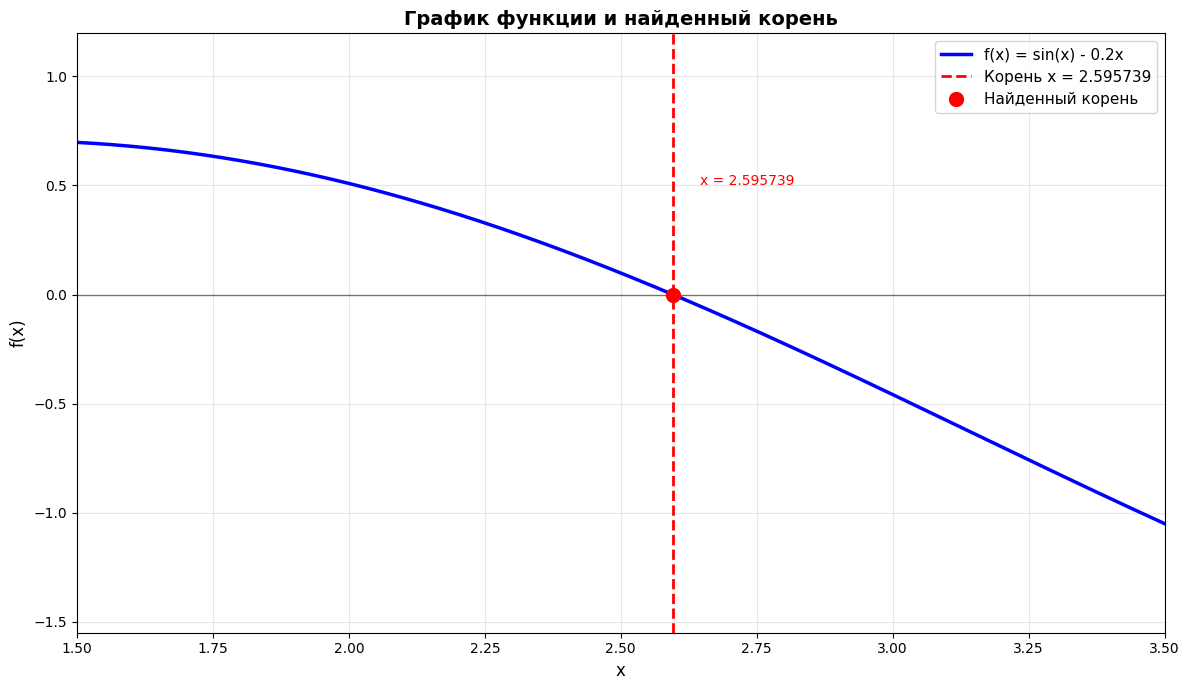

In [20]:
# Импортируем все функции из библиотек (звёздочка)
from math import *
from numpy import *
from matplotlib.pyplot import *

# Определяем функцию и её производную для уравнения sin(x) - 0.2x = 0
def f(x):
    """Исходная функция: sin(x) - 0.2*x"""
    return sin(x) - 0.2 * x

def f_prime(x):
    """Первая производная: cos(x) - 0.2"""
    return cos(x) - 0.2

def find_root(a, b, eps=1e-6):
    print("Комбинированный метод хорд и касательных")
    print(f"Интервал: [{a}, {b}], точность: {eps}")
    print(f"{'Итерация':<10} {'x':<15} {'f(x)':<15}")
    
    for i in range(50):
        # Метод хорд (секущих)
        x_chord = a - f(a) * (b - a) / (f(b) - f(a))
        
        # Метод касательных (Ньютона) – выбираем конец интервала для касательной
        # Если в точке b знаки функции и производной совпадают, касательная из b,
        # иначе – из a.
        if f(b) * f_prime(b) > 0:
            x_tangent = b - f(b) / f_prime(b)
        else:
            x_tangent = a - f(a) / f_prime(a)
        
        # Комбинированное приближение – среднее арифметическое двух методов
        x = (x_chord + x_tangent) / 2
        
        print(f"{i+1:<10} {x:<15.8f} {f(x):<15.8f}")
        
        # Проверка достижения точности
        if abs(f(x)) < eps:
            return x, i+1
        
        # Сужаем интервал, сохраняя корень внутри
        if f(a) * f(x) < 0:
            b = x   # корень между a и x
        else:
            a = x   # корень между x и b
    
    # Если за 50 итераций точность не достигнута, возвращаем середину последнего интервала
    return (a + b) / 2, 50

# --- Основная часть программы ---
a0, b0 = 2.0, 3.0      # интервал, на котором функция меняет знак (f(2)>0, f(3)<0)
eps = 1e-6

root, iter_n = find_root(a0, b0, eps)

print(f"КОРЕНЬ: x = {root:.8f}")
print(f"Итераций: {iter_n}")
print(f"Проверка: f(x) = {f(root):.8f}")
print()

# --- Построение графика ---
x_vals = linspace(1.5, 3.5, 300)               # массив значений x
y_vals = [sin(xi) - 0.2 * xi for xi in x_vals] # соответствующие значения f(x)

figure(figsize=(12, 7))
plot(x_vals, y_vals, 'b-', linewidth=2.5, label='f(x) = sin(x) - 0.2x')
axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)  # ось OX
axvline(x=root, color='red', linestyle='--', linewidth=2, label=f'Корень x = {root:.6f}')
plot(root, f(root), 'ro', markersize=10, label='Найденный корень')
grid(True, alpha=0.3)
xlabel('x', fontsize=12)
ylabel('f(x)', fontsize=12)
title('График функции и найденный корень', fontsize=14, fontweight='bold')
legend(fontsize=11)
xlim(1.5, 3.5)
ylim(min(y_vals) - 0.5, max(y_vals) + 0.5)
text(root + 0.05, 0.5, f'x = {root:.6f}', fontsize=10, color='red')
tight_layout()
show()

Задание 5

Решение с использованием инструментального пакета SciPy (аналог fzero в MATLAB, root в MathCad):
Корень уравнения: x = 2.59573908
Значение функции в корне: f(x) = 1.11e-16
Информация о решении: The solution converged.
Число вычислений функции: 9

Сопоставление с результатом комбинированного метода:
Комбинированный метод:      x = 2.59574350
SciPy (инструментальный):   x = 2.59573908
Разница: 4.42e-06

Различие превышает 1e-6, что может быть связано с округлением.


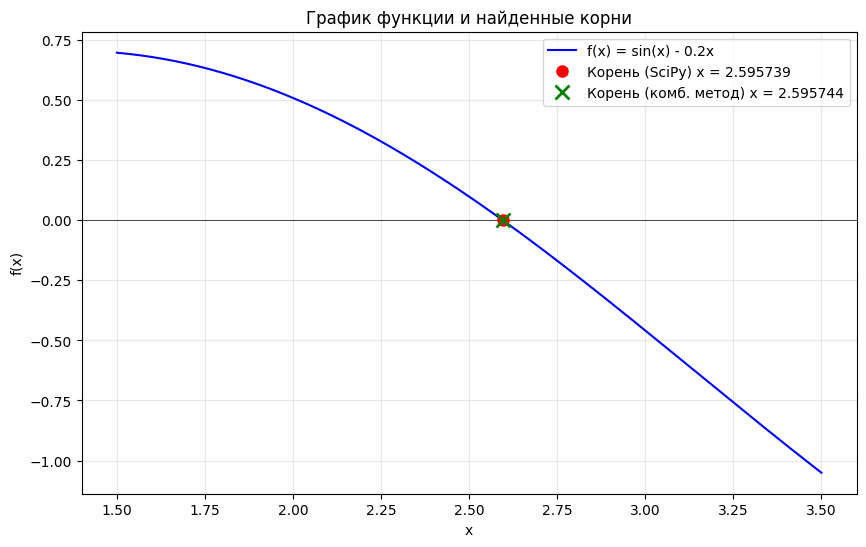

In [24]:
# Импорт библиотек для численного решения (аналог fzero в MATLAB / root в MathCad)
import numpy as np
from scipy.optimize import root

# Определяем функцию
def f(x):
    return np.sin(x) - 0.2 * x

# Используем инструментальный пакет SciPy (метод 'hybr' — аналог гибридного метода Пауэлла,
# который используется в MATLAB fzero и MathCad root)
x0 = 2.5  # начальное приближение
sol = root(f, x0, method='hybr', tol=1e-12)  # высокая точность для сравнения

root_scipy = sol.x[0]
f_root = f(root_scipy)

print("Решение с использованием инструментального пакета SciPy (аналог fzero в MATLAB, root в MathCad):")
print(f"Корень уравнения: x = {root_scipy:.8f}")
print(f"Значение функции в корне: f(x) = {f_root:.2e}")
print(f"Информация о решении: {sol.message}")
print(f"Число вычислений функции: {sol.nfev}")

# Результат, полученный ранее комбинированным методом хорд и касательных
root_combined = 2.59574350

print("\nСопоставление с результатом комбинированного метода:")
print(f"Комбинированный метод:      x = {root_combined:.8f}")
print(f"SciPy (инструментальный):   x = {root_scipy:.8f}")
print(f"Разница: {abs(root_combined - root_scipy):.2e}")

# Проверка достижения требуемой точности 1e-6
if abs(root_combined - root_scipy) < 1e-6:
    print("\nОба метода дают корень с точностью лучше 1e-6.")
else:
    print("\nРазличие превышает 1e-6, что может быть связано с округлением.")

# Дополнительно: построение графика (для визуализации)
import matplotlib.pyplot as plt

x_vals = np.linspace(1.5, 3.5, 300)
y_vals = f(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', label='f(x) = sin(x) - 0.2x')
plt.axhline(0, color='black', linewidth=0.5)
plt.plot(root_scipy, f(root_scipy), 'ro', markersize=8, label=f'Корень (SciPy) x = {root_scipy:.6f}')
plt.plot(root_combined, f(root_combined), 'gx', markersize=10, markeredgewidth=2, label=f'Корень (комб. метод) x = {root_combined:.6f}')
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('График функции и найденные корни')
plt.legend()
plt.show()